In [ ]:
      import sys; sys.path.append('..')
      import pandas as pd
      from src.summarization.summarizer import build_category_article

      df = pd.read_csv('../datasets/clusters_with_reviews.csv')

      for category in df['cluster_id'].unique():
          subset = df[df['cluster_id'] == category]
          result = build_category_article(subset, category_label=category)
          print(f"\n=== {category} ({len(subset)} reviews) ===")
          print("Top products:", [p['product_title'] for p in result['top_products']])
          print("Worst product:", result['worst_product'])
          print("Article:\n", result['article'])

Your max_length is set to 20, but your input_length is only 18. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=9)



=== Fire Tablets (29280 reviews) ===
Top products: ['Amazon Fire Hd 10 Tablet', 'Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android', 'Amazon Fire Kids Edition Tablet']
Worst product: {'product': 'Fire Tablet', 'avg_rating': 4.4621488138612255, 'count': 12351}
Article:
 ## Best in Fire Tablets

**Amazon Fire Hd 10 Tablet** (avg 4.8/5, 128 reviews)
Common complaints: The Amazon Echo is a wonderful device, but its use is fairly limited. It allows you to turn on and off lights, but you cannot add timers to the control instructions.

**Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android** (avg 4.7/5, 135 reviews)
Common complaints: i cant at night it has no back light from one to ten its a 7.

**Amazon Fire Kids Edition Tablet** (avg 4.8/5, 6 reviews)
Common complaints: no major complaints found

## Avoid: Fire Tablet
Rated 4.5/5 across 12351 reviews - the lowest in this category. This device is OK for reading or listening to audiobooks via Overd

## The generated articles have real quality problems, independent of the labeling issue:

Grammar/typos are leaking straight from source reviews into the "summary" ("tokd", "avG", "cannot adjust the brightness" mid-sentence) — BART is quoting/lightly rephrasing input almost verbatim rather than truly summarizing
Article for cluster 0 doesn't even mention it's about "top 3 products" clearly — reads as one product's review pasted in
Article for cluster 3 doesn't reference top products or worst product at all — it's just paraphrasing one negative review

This tells me the structured passage BART receives is too close to raw review text, and BART is doing light extractive summarization rather than the structured "top 3 + differences + complaints + worst" article your brief asks for. That's a src/summarization/summarizer.py prompt-engineering problem, not an environment problem.

## SETUP for tests

In [2]:
%pip install matplotlib
import sys
sys.path.append('..')  # adjust depth if needed for wherever this notebook lives

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

from src.sentiment.classifier import rating_to_sentiment

df = pd.read_csv('../datasets/clean_reviews.csv')
df['true_sentiment'] = df['star_rating'].apply(rating_to_sentiment)

# One shared split, used by ALL three approaches below - critical for a fair comparison.
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['true_sentiment']
)

# Keep the eval sample small enough that the OpenAI pass (slowest, costs money)
# finishes in reasonable time. Same sample used for all three models.
EVAL_N = 500
eval_df = test_df.sample(n=min(EVAL_N, len(test_df)), random_state=42).reset_index(drop=True)

LABELS = ['negative', 'neutral', 'positive']
print(f"Train size: {len(train_df)} | Shared eval set: {len(eval_df)}")
print(eval_df['true_sentiment'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 12.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Train size: 37500 | Shared eval set: 500
true_sentiment
positive    470
neutral      16
negative     14
Name: count, dtype: int64


RESULTS:
Train size: 37500 | Shared eval set: 500
true_sentiment
positive    470
neutral      16
negative     14
Name: count, dtype: int64

## Reusable evaluation function

In [3]:
def evaluate_predictions(y_true, y_pred, model_name: str):
    """Compute + print + plot metrics for one model's predictions. Returns a results dict."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )
    macro_f1 = f1.mean()

    print(f"\n{'='*50}\n{model_name}\n{'='*50}")
    print(f"Accuracy: {acc:.2%}  |  Macro F1: {macro_f1:.2%}\n")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'../datasets/confusion_matrix_{model_name.lower().replace(" ", "_")}.png')
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "precision_per_class": dict(zip(LABELS, precision)),
        "recall_per_class": dict(zip(LABELS, recall)),
        "f1_per_class": dict(zip(LABELS, f1)),
    }

all_results = []

## Local RoBERTa (pretrained transformer)

/opt/anaconda3/envs/reviews-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/reviews-project/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.



Local RoBERTa
Accuracy: 90.00%  |  Macro F1: 52.82%

              precision    recall  f1-score   support

    negative       0.43      0.71      0.54        14
     neutral       0.07      0.12      0.09        16
    positive       0.98      0.93      0.95       470

    accuracy                           0.90       500
   macro avg       0.49      0.59      0.53       500
weighted avg       0.93      0.90      0.91       500



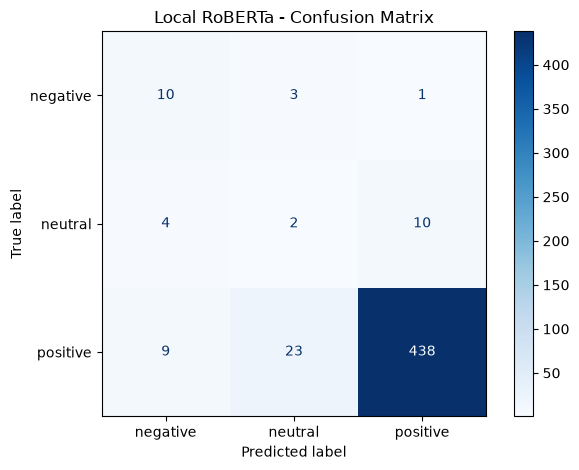

In [4]:
import os
os.environ.pop("OPENAI_API_KEY", None)  # make sure this run uses the LOCAL backend

from src.sentiment.classifier import predict_sentiment_batch

preds = predict_sentiment_batch(eval_df['review_text'].tolist())
eval_df['pred_roberta'] = [p['label'] for p in preds]

result = evaluate_predictions(eval_df['true_sentiment'], eval_df['pred_roberta'], "Local RoBERTa")
all_results.append(result)

## Random Forest (TF-IDF)


Random Forest
Accuracy: 94.40%  |  Macro F1: 40.70%

              precision    recall  f1-score   support

    negative       1.00      0.14      0.25        14
     neutral       0.00      0.00      0.00        16
    positive       0.94      1.00      0.97       470

    accuracy                           0.94       500
   macro avg       0.65      0.38      0.41       500
weighted avg       0.92      0.94      0.92       500



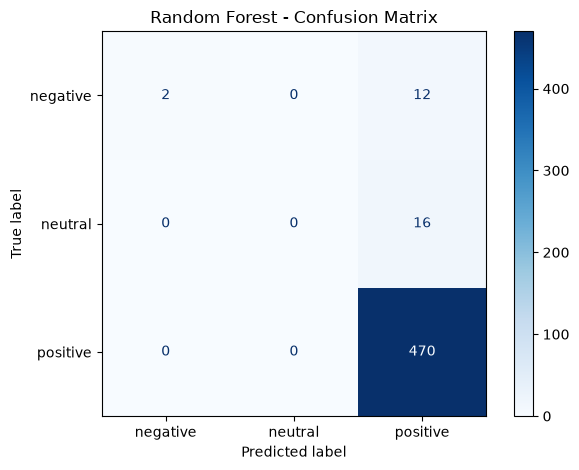

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Train on train_df only - never touches eval_df, so this is a fair held-out test
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_vec = vectorizer.fit_transform(train_df['review_text'].astype(str))
X_eval_vec = vectorizer.transform(eval_df['review_text'].astype(str))

rf_clf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_clf.fit(X_train_vec, train_df['sentiment'] if 'sentiment' in train_df.columns else train_df['true_sentiment'])

eval_df['pred_rf'] = rf_clf.predict(X_eval_vec)

result = evaluate_predictions(eval_df['true_sentiment'], eval_df['pred_rf'], "Random Forest")
all_results.append(result)

## OpenAI - LLM

/opt/anaconda3/envs/reviews-project/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.



OpenAI (gpt-5.4-mini)
Accuracy: 90.00%  |  Macro F1: 52.82%

              precision    recall  f1-score   support

    negative       0.43      0.71      0.54        14
     neutral       0.07      0.12      0.09        16
    positive       0.98      0.93      0.95       470

    accuracy                           0.90       500
   macro avg       0.49      0.59      0.53       500
weighted avg       0.93      0.90      0.91       500



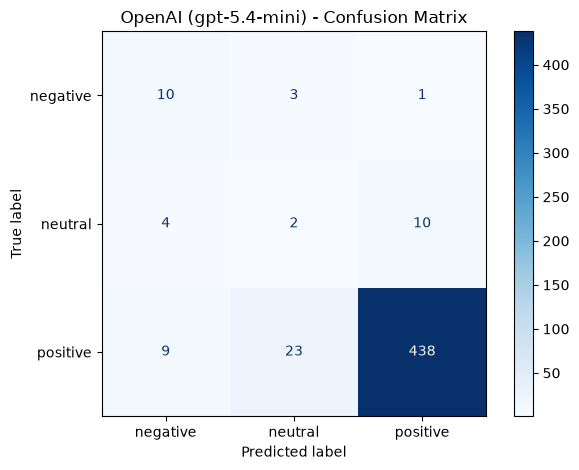

''

In [12]:
#%pip install openai
from openai import OpenAI
import getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Reload the module so it picks up the env var fresh (lru_cache on the client otherwise persists)
import importlib
import src.sentiment.classifier as classifier_module
importlib.reload(classifier_module)

preds = classifier_module.predict_sentiment_batch(eval_df['review_text'].tolist())
eval_df['pred_openai'] = [p['label'] for p in preds]

result = evaluate_predictions(eval_df['true_sentiment'], eval_df['pred_openai'], "OpenAI (gpt-5.4-mini)")
all_results.append(result)

# Clear the key from this session once done, so it's not sitting in memory/notebook state
os.environ.pop("OPENAI_API_KEY", None)


==================================================
OpenAI (gpt-5.4-mini) - no additional Prompts 
==================================================
Accuracy: 90.60%  |  Macro F1: 55.45%

              precision    recall  f1-score   support

    negative       0.44      1.00      0.61        14
     neutral       0.08      0.12      0.10        16
    positive       0.99      0.93      0.96       470

    accuracy                           0.91       500
   macro avg       0.50      0.68      0.55       500
weighted avg       0.94      0.91      0.92       500

==================================================
OpenAI (gpt-5.4-mini) - optimised prompts to deal with neutral - it got worse
==================================================
Accuracy: 90.00%  |  Macro F1: 52.82%

              precision    recall  f1-score   support

    negative       0.43      0.71      0.54        14
     neutral       0.07      0.12      0.09        16
    positive       0.98      0.93      0.95       470

    accuracy                           0.90       500
   macro avg       0.49      0.59      0.53       500
weighted avg       0.93      0.90      0.91       500

## Comparison table + chart for the report

                Model  Accuracy  Macro F1  F1 (negative)  F1 (neutral)  F1 (positive)
 OpenAI (gpt-4o-mini)     0.916  0.564431       0.622222      0.108108       0.962963
OpenAI (gpt-5.4-mini)     0.906  0.554513       0.608696      0.097561       0.957284
        Local RoBERTa     0.900  0.528220       0.540541      0.090909       0.953210
        Random Forest     0.944  0.407025       0.250000      0.000000       0.971074


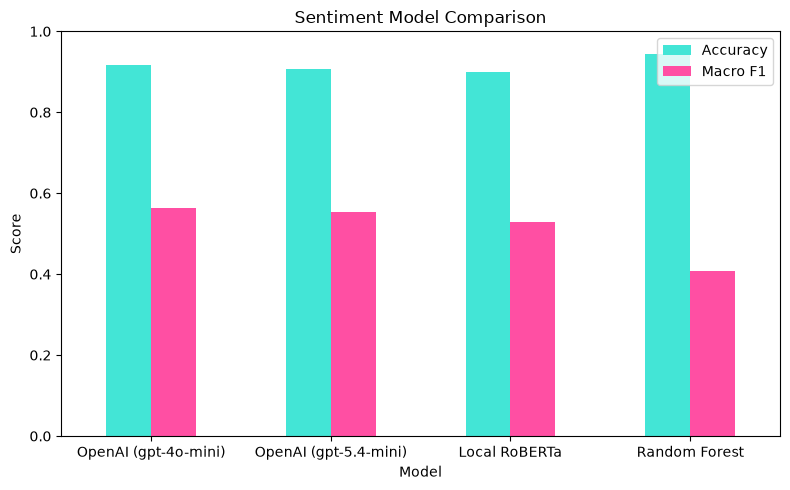

In [11]:
comparison_df = pd.DataFrame([
    {
        "Model": r["model"],
        "Accuracy": r["accuracy"],
        "Macro F1": r["macro_f1"],
        "F1 (negative)": r["f1_per_class"]["negative"],
        "F1 (neutral)": r["f1_per_class"]["neutral"],
        "F1 (positive)": r["f1_per_class"]["positive"],
    }
    for r in all_results
])
comparison_df = comparison_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('../datasets/sentiment_model_comparison.csv', index=False)

# Bar chart for the report
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df.plot(x="Model", y=["Accuracy", "Macro F1"], kind="bar", ax=ax, color=['#43e5d6', '#ff4fa3'])
plt.title("Sentiment Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../datasets/sentiment_model_comparison_chart.png')
plt.show()